In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/bccd-dataset-with-mask/BCCD Dataset with mask/test/original/fc15659f-6264-4dd5-ab17-43d89fb297b9.png
/kaggle/input/bccd-dataset-with-mask/BCCD Dataset with mask/test/original/f8a8b148-60e4-4a5c-ae19-941b19ec0846.png
/kaggle/input/bccd-dataset-with-mask/BCCD Dataset with mask/test/original/e6d7c5e1-43fc-4712-86d5-aa70252b978f.png
/kaggle/input/bccd-dataset-with-mask/BCCD Dataset with mask/test/original/fcc2b245-f47f-447f-8527-275b0005677c.png
/kaggle/input/bccd-dataset-with-mask/BCCD Dataset with mask/test/original/f65a1633-9935-4984-a285-a60d30aa1707.png
/kaggle/input/bccd-dataset-with-mask/BCCD Dataset with mask/test/original/f24c8fe0-a534-44cf-9995-b2b314d945ba.png
/kaggle/input/bccd-dataset-with-mask/BCCD Dataset with mask/test/original/e3e9c2de-0a24-4c7e-8a69-3d3093d5bdab.png
/kaggle/input/bccd-dataset-with-mask/BCCD Dataset with mask/test/original/e61e6af2-7f8b-47b0-bbe7-acb2ed0299ab.png
/kaggle/input/bccd-dataset-with-mask/BCCD Dataset with mask/test/original/f8b14f

In [1]:
!pip install scikit-fuzzy


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 13.6 MB/s eta 0:00:00 0:00:01


In [29]:
import os
import cv2
import numpy as np
import skfuzzy as fuzz
from tqdm import tqdm
from skimage.segmentation import find_boundaries
from scipy.spatial.distance import cdist

In [30]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    print(root)

/kaggle/input
/kaggle/input/bccd-dataset-with-mask
/kaggle/input/bccd-dataset-with-mask/BCCD Dataset with mask
/kaggle/input/bccd-dataset-with-mask/BCCD Dataset with mask/test
/kaggle/input/bccd-dataset-with-mask/BCCD Dataset with mask/test/original
/kaggle/input/bccd-dataset-with-mask/BCCD Dataset with mask/test/mask
/kaggle/input/bccd-dataset-with-mask/BCCD Dataset with mask/train
/kaggle/input/bccd-dataset-with-mask/BCCD Dataset with mask/train/original
/kaggle/input/bccd-dataset-with-mask/BCCD Dataset with mask/train/mask


In [31]:
# PATHS
TEST_IMG = "/kaggle/input/bccd-dataset-with-mask/BCCD Dataset with mask/test/original"
TEST_MASK = "/kaggle/input/bccd-dataset-with-mask/BCCD Dataset with mask/test/mask"

# BUILD MASK DICTIONARY 
mask_files = os.listdir(TEST_MASK)
mask_dict = {os.path.splitext(m)[0]: m for m in mask_files}

# IMAGE LIST 
test_images = [f for f in sorted(os.listdir(TEST_IMG))
               if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

# BOUNDARY F1 FUNCTION 
def boundary_f1(pred, gt, tolerance=2):

    pred_pts = np.argwhere(pred > 0)
    gt_pts   = np.argwhere(gt > 0)

    if len(pred_pts) == 0 or len(gt_pts) == 0:
        return 0

    dist = cdist(pred_pts, gt_pts)

    pred_match = np.sum(np.min(dist, axis=1) <= tolerance)
    gt_match   = np.sum(np.min(dist, axis=0) <= tolerance)

    precision = pred_match / len(pred_pts)
    recall    = gt_match / len(gt_pts)

    if precision + recall == 0:
        return 0

    return 2 * precision * recall / (precision + recall)

# MAIN LOOP
kmeans_scores = []
fcm_scores = []

for name in tqdm(test_images):

    key = os.path.splitext(name)[0]

    if key not in mask_dict:
        continue

    img_path = os.path.join(TEST_IMG, name)
    mask_path = os.path.join(TEST_MASK, mask_dict[key])

    img = cv2.imread(img_path)
    gt  = cv2.imread(mask_path, 0)

    if img is None or gt is None:
        continue

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    gt  = (gt > 0).astype(np.uint8)

    # RESIZE FOR SPEED 
    img_small = cv2.resize(img, (256, 256))
    gt_small  = cv2.resize(gt, (256, 256), interpolation=cv2.INTER_NEAREST)

    lab = cv2.cvtColor(img_small, cv2.COLOR_RGB2LAB)
    pixel_values = lab.reshape((-1, 3)).astype(np.float32)

    # KMEANS 
    _, labels, _ = cv2.kmeans(
        pixel_values, 3, None,
        (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2),
        10, cv2.KMEANS_RANDOM_CENTERS
    )

    seg_k = labels.reshape((256, 256))

    scores = []
    for i in range(3):
        scores.append(np.sum((seg_k == i) * gt_small))

    k_mask = (seg_k == np.argmax(scores)).astype(np.uint8)

    # FCM 
    data = pixel_values.T

    cntr, u, _, _, _, _, _ = fuzz.cluster.cmeans(
        data, c=3, m=2, error=0.005, maxiter=300
    )

    seg_f = np.argmax(u, axis=0).reshape((256, 256))

    scores = []
    for i in range(3):
        scores.append(np.sum((seg_f == i) * gt_small))

    f_mask = (seg_f == np.argmax(scores)).astype(np.uint8)

    # BOUNDARIES 
    b_gt = find_boundaries(gt_small, mode='inner')
    b_k  = find_boundaries(k_mask, mode='inner')
    b_f  = find_boundaries(f_mask, mode='inner')

    # SCORES 
    kmeans_scores.append(boundary_f1(b_k, b_gt))
    fcm_scores.append(boundary_f1(b_f, b_gt))

# FINAL RESULT
print("\nFINAL TEST RESULTS ")
print("Images evaluated:", len(kmeans_scores))
print("Average Boundary F1 - KMeans :", np.mean(kmeans_scores))
print("Average Boundary F1 - FCM    :", np.mean(fcm_scores))

100%|██████████| 159/159 [03:49<00:00,  1.44s/it]


========= FINAL TEST RESULTS =========
Images evaluated: 159
Average Boundary F1 - KMeans : 0.7820610658508943
Average Boundary F1 - FCM    : 0.7673505237055535


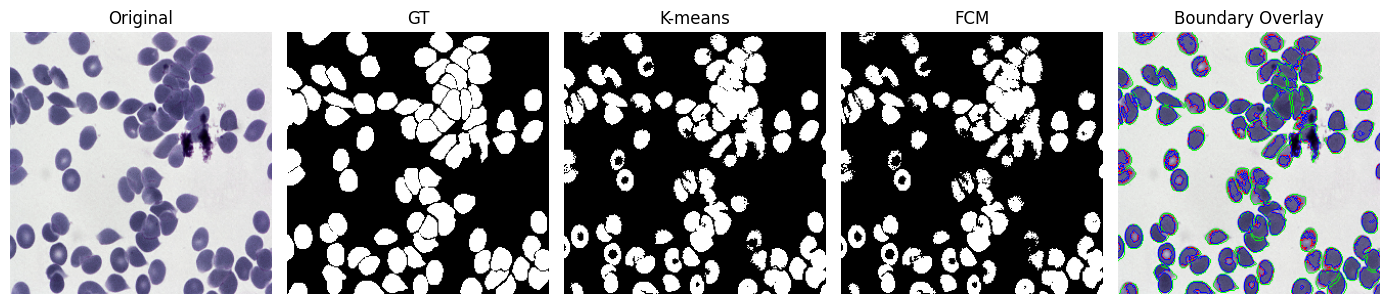

In [33]:
import matplotlib.pyplot as plt
import random

name = random.choice(test_images)
# name = "BloodImage_00000.jpg"

key = os.path.splitext(name)[0]

if key not in mask_dict:
    raise ValueError("Mask not found for this image")

img_path  = os.path.join(TEST_IMG, name)
mask_path = os.path.join(TEST_MASK, mask_dict[key])

img = cv2.imread(img_path)
gt  = cv2.imread(mask_path, 0)

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
gt  = (gt > 0).astype(np.uint8)

img_small = cv2.resize(img, (256, 256))
gt_small  = cv2.resize(gt, (256, 256), interpolation=cv2.INTER_NEAREST)

lab = cv2.cvtColor(img_small, cv2.COLOR_RGB2LAB)
pixel_values = lab.reshape((-1, 3)).astype(np.float32)

_, labels, _ = cv2.kmeans(
    pixel_values, 3, None,
    (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2),
    10, cv2.KMEANS_RANDOM_CENTERS
)

seg_k = labels.reshape((256, 256))
scores = [np.sum((seg_k == i) * gt_small) for i in range(3)]
k_mask = (seg_k == np.argmax(scores)).astype(np.uint8)

data = pixel_values.T

cntr, u, _, _, _, _, _ = fuzz.cluster.cmeans(
    data, c=3, m=2, error=0.005, maxiter=300
)

seg_f = np.argmax(u, axis=0).reshape((256, 256))
scores = [np.sum((seg_f == i) * gt_small) for i in range(3)]
f_mask = (seg_f == np.argmax(scores)).astype(np.uint8)

b_gt = find_boundaries(gt_small, mode='inner')
b_k  = find_boundaries(k_mask, mode='inner')
b_f  = find_boundaries(f_mask, mode='inner')

overlay = img_small.copy()
overlay[b_gt] = [0, 255, 0]
overlay[b_k]  = [255, 0, 0]
overlay[b_f]  = [0, 0, 255]

plt.figure(figsize=(14,6))

plt.subplot(1,5,1)
plt.imshow(img_small)
plt.title("Original")
plt.axis("off")

plt.subplot(1,5,2)
plt.imshow(gt_small, cmap="gray")
plt.title("GT")
plt.axis("off")

plt.subplot(1,5,3)
plt.imshow(k_mask, cmap="gray")
plt.title("K-means")
plt.axis("off")

plt.subplot(1,5,4)
plt.imshow(f_mask, cmap="gray")
plt.title("FCM")
plt.axis("off")

plt.subplot(1,5,5)
plt.imshow(overlay)
plt.title("Boundary Overlay")
plt.axis("off")

plt.tight_layout()
plt.show()
